In [28]:
%load_ext autoreload
%autoreload 2
import retineuron
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import skeleton_plot as skpl

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
v_field_pth = '/Users/emilyjoyce/repos/RPSim/user_files/user_output/23_37_58-2026_05_09/post_process/single_center_pixel_PS100_30Hz.pkl'
v_field = retineuron.electric.Electrode(v_field_pth)

In [3]:
v_field.pull_xyzt(1,10,100,0)

-0.0173113780814127

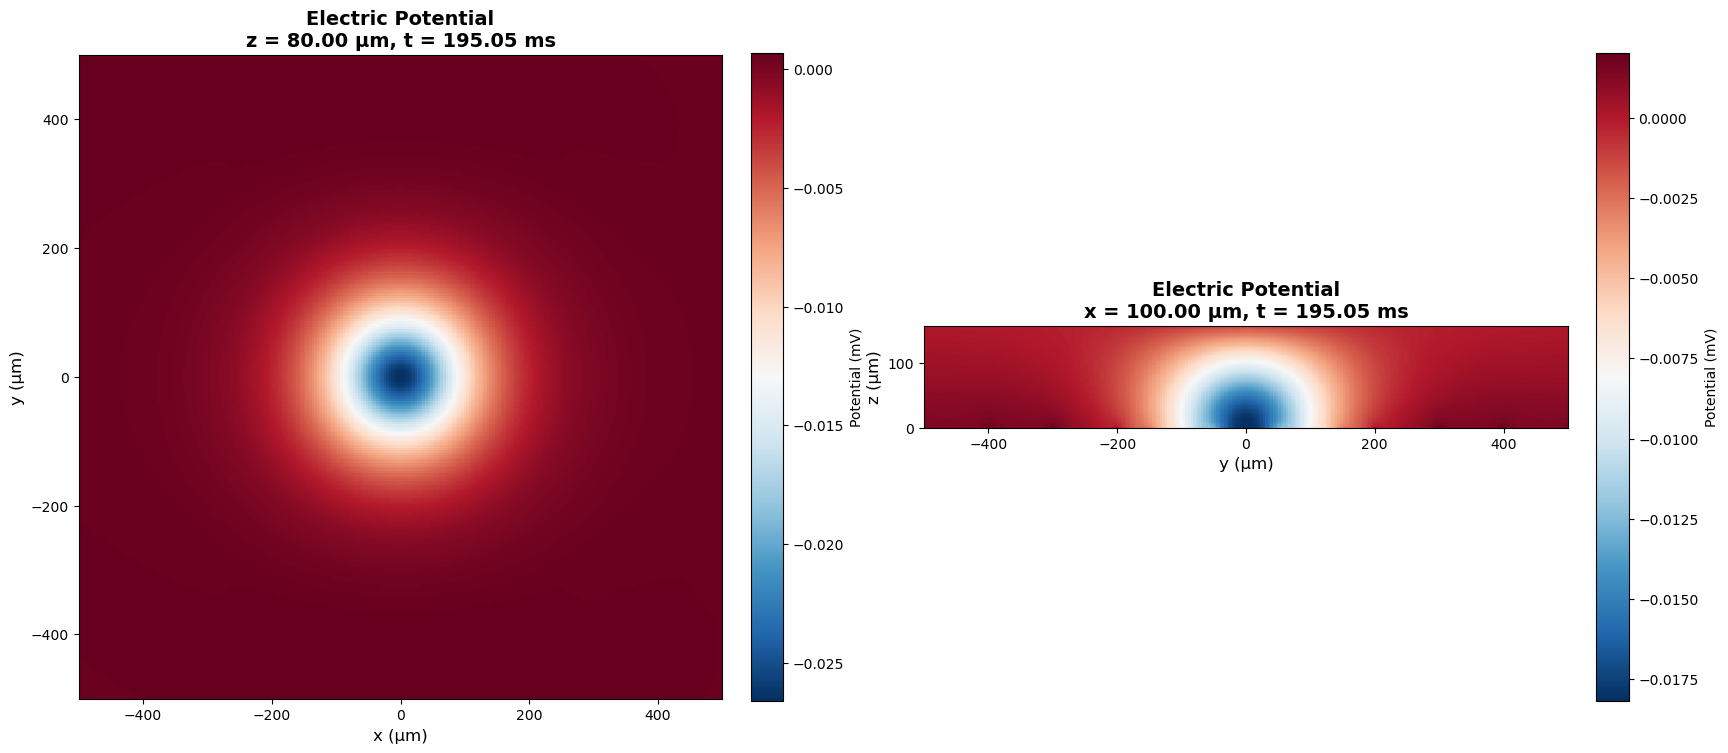

In [19]:
# Plot x-y plane at middle z, at time 10ms
fig, ax = plt.subplots(1,2, figsize = (20,10))
retineuron.plot.plot_electric_potential(v_field, time=10.0, axis='z', ax = ax[0],
                                                 xlim = (-500,500),
                                                 ylim = (-500,500))


# Plot y-z plane at specific x coordinate
fig, ax = retineuron.plot.plot_electric_potential(v_field, time=10.0, axis='x', index=100.0,
                                                 xlim = (-500,500), ax = ax[1])

In [20]:
s1_pth = '/Users/emilyjoyce/Downloads/swc-morphologies/bp1-0.05um.swc'
s2_pth = '/Users/emilyjoyce/Downloads/swc-morphologies/bp2-0.05um.swc'
h_pth = '/Users/emilyjoyce/Downloads/swc-morphologies/h1.swc'

In [23]:

cols = ["id", "type", "x", "y", "z", "radius", "parent"]

swc1 = pd.read_csv(
    s1_pth,
    comment="#",
    sep=r"\s+",
    names=cols
)
swc2 = pd.read_csv(
    s2_pth,
    comment="#",
    sep=r"\s+",
    names=cols
)

swc3 = pd.read_csv(
    h_pth,
    comment="#",
    sep=r"\s+",
    names=cols
)

In [24]:
# get the min y value in these three, subtract from all y valuse
min_y = np.min(np.hstack([swc1['y'].values, swc2['y'].values, swc3['y'].values]))

In [25]:
swc1.loc[:,'y'] = swc1['y'].values-min_y
swc2.loc[:,'y'] = swc2['y'].values-min_y
swc3.loc[:,'y'] = swc3['y'].values-min_y

In [26]:
# then zero around avg bipolar soma locs
# i think the first line is near the soma
soma1 = swc1.loc[0,['x','z']].values
soma2 = swc2.loc[0,['x','z']].values
soma_xz = np.mean([soma1, soma2], axis = 0)
swc1.loc[:,'x'] = swc1['x'].values-soma_xz[0]
swc2.loc[:,'x'] = swc2['x'].values-soma_xz[0]
swc3.loc[:,'x'] = swc3['x'].values-soma_xz[0]

swc1.loc[:,'z'] = swc1['z'].values-soma_xz[1]
swc2.loc[:,'z'] = swc2['z'].values-soma_xz[1]
swc3.loc[:,'z'] = swc3['z'].values-soma_xz[1]

In [27]:
verts_1 = swc1[['x','y','z']].values
edges_1 = swc1[['id','parent']].iloc[1:].values-1
verts_2 = swc2[['x','y','z']].values
edges_2 = swc2[['id','parent']].iloc[1:].values-1
verts_h = swc3[['x','y','z']].values
edges_h = swc3[['id','parent']].iloc[1:].values-1

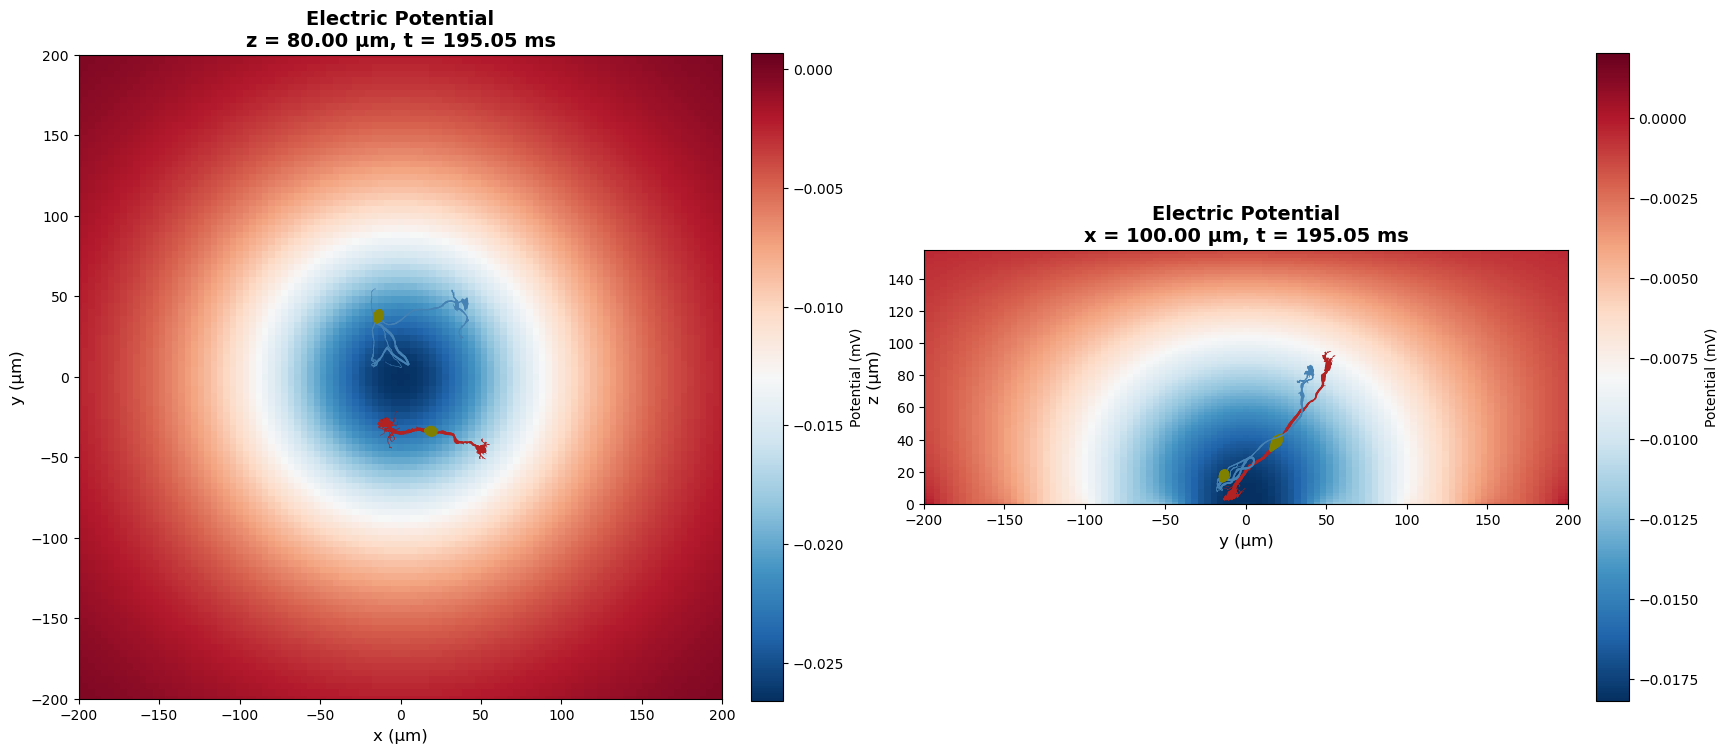

In [39]:
# Plot x-y plane at middle z, at time 10ms
fig, ax = plt.subplots(1,2, figsize = (20,10))

skpl.plot_tools.plot_verts(verts_2, edges_2, radius = swc2['radius'], x = 'x', y = 'z', ax = ax[0],
                               skel_color_map={3: 'firebrick', 4: 'salmon', 2: 'steelblue', 1: 'olive',},
                                  plot_soma = False, soma_size = 300, skel_colors = swc2['type'],
                          line_width=2)
skpl.plot_tools.plot_verts(verts_1, edges_1, radius = swc1['radius'], x = 'x', y = 'z', ax = ax[0],
                               skel_color_map={3: 'steelblue', 4: 'salmon', 2: 'steelblue', 1: 'olive',},
                                  plot_soma = False, soma_size = 300, skel_colors = swc1['type'],
                          line_width=2)
retineuron.plot.plot_electric_potential(v_field, time=10.0, axis='z', ax = ax[0],
                                                 xlim = (-200,200),
                                                 ylim = (-200,200))



skpl.plot_tools.plot_verts(verts_2, edges_2, radius = swc2['radius'], x = 'x', y = 'y', ax = ax[1],
                               skel_color_map={3: 'firebrick', 4: 'salmon', 2: 'steelblue', 1: 'olive',},
                                  plot_soma = False, soma_size = 300, skel_colors = swc2['type'],
                          line_width=2)
skpl.plot_tools.plot_verts(verts_1, edges_1, radius = swc1['radius'], x = 'x', y = 'y', ax = ax[1],
                               skel_color_map={3: 'steelblue', 4: 'salmon', 2: 'steelblue', 1: 'olive',},
                                  plot_soma = False, soma_size = 300, skel_colors = swc1['type'],
                          line_width=2)


# Plot y-z plane at specific x coordinate
fig, ax = retineuron.plot.plot_electric_potential(v_field, time=10.0, axis='x', index=100.0,
                                                 xlim = (-200,200), ax = ax[1])

In [40]:
t_swc = '/Users/emilyjoyce/ucsb/bionicvision/projects/neuron/skeletons/first_skels/skels_electrode_space/curly_bb.swc'
t_swc = pd.read_csv(
    t_swc,
    comment="#",
    sep=r"\s+",
    names=cols
)

In [41]:
verts_t = t_swc[['x','y','z']].values
edges_t = t_swc[['id','parent']].iloc[1:].values-1


In [53]:
np.sum(verts_t!=verts_1)

660

In [54]:
verts_1[(verts_t!=verts_1)][1],verts_t[(verts_t!=verts_1)][1]

(15.738399999999999, 15.7384)

In [57]:
# ok that's fine lol 
# try loading as Cell obj 
curly_bb_path = '/Users/emilyjoyce/ucsb/bionicvision/projects/neuron/skeletons/first_skels/skels_electrode_space/curly_bb.swc'
curly = retineuron.cell.Cell(curly_bb_path)

In [59]:
curly.edges

array([[   0,    1],
       [   1,    2],
       [   2,    3],
       ...,
       [1672, 1673],
       [1672, 1685],
       [1240, 1691]])

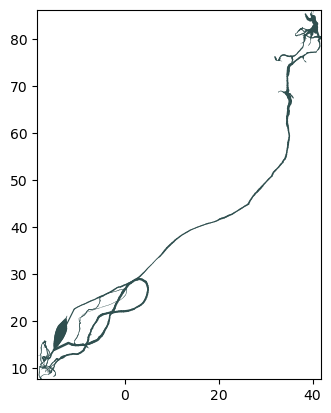

In [61]:
skpl.plot_tools.plot_verts(curly.verts, curly.edges, radius = curly.radii, x = 'x', y = 'y',
                               skel_color_map={3: 'steelblue', 4: 'salmon', 2: 'steelblue', 1: 'olive',},
                                  plot_soma = False, soma_size = 300,
                          line_width=2)

In [68]:
sim = retineuron.simulation.ExtracellularSimulation(curly, v_field)

In [69]:
sim.compute_segment_potentials()

array([[-0.06273823, -0.06273823, -0.06273823, ..., -0.05641551,
        -0.05641551, -0.05641551],
       [-0.06526006, -0.06526006, -0.06526006, ..., -0.05995163,
        -0.05995163, -0.05995163],
       [-0.05424872, -0.05424872, -0.05424872, ..., -0.04655848,
        -0.04655848, -0.04655848],
       ...,
       [-0.02384634, -0.02384634, -0.02384634, ..., -0.00589969,
        -0.00589969, -0.00589969],
       [-0.02374213, -0.02374213, -0.02374213, ..., -0.00598883,
        -0.00598883, -0.00598883],
       [-0.02338269, -0.02338269, -0.02338269, ..., -0.00609447,
        -0.00609447, -0.00609447]])

In [71]:
sim.apply_extracellular_potential()

In [73]:
sim.run()

{'t_ms': array([ 0.   ,  0.025,  0.05 ,  0.075,  0.1  ,  0.125,  0.15 ,  0.175,
         0.2  ,  0.225,  0.25 ,  0.275,  0.3  ,  0.325,  0.35 ,  0.375,
         0.4  ,  0.425,  0.45 ,  0.475,  0.5  ,  0.525,  0.55 ,  0.575,
         0.6  ,  0.625,  0.65 ,  0.675,  0.7  ,  0.725,  0.75 ,  0.775,
         0.8  ,  0.825,  0.85 ,  0.875,  0.9  ,  0.925,  0.95 ,  0.975,
         1.   ,  1.025,  1.05 ,  1.075,  1.1  ,  1.125,  1.15 ,  1.175,
         1.2  ,  1.225,  1.25 ,  1.275,  1.3  ,  1.325,  1.35 ,  1.375,
         1.4  ,  1.425,  1.45 ,  1.475,  1.5  ,  1.525,  1.55 ,  1.575,
         1.6  ,  1.625,  1.65 ,  1.675,  1.7  ,  1.725,  1.75 ,  1.775,
         1.8  ,  1.825,  1.85 ,  1.875,  1.9  ,  1.925,  1.95 ,  1.975,
         2.   ,  2.025,  2.05 ,  2.075,  2.1  ,  2.125,  2.15 ,  2.175,
         2.2  ,  2.225,  2.25 ,  2.275,  2.3  ,  2.325,  2.35 ,  2.375,
         2.4  ,  2.425,  2.45 ,  2.475,  2.5  ,  2.525,  2.55 ,  2.575,
         2.6  ,  2.625,  2.65 ,  2.675,  2.7  ,  2.725, 

(<Figure size 1500x1000 with 7 Axes>,
 <Axes: title={'center': 'Cell extracellular voltage at t = 200.05 ms'}>)

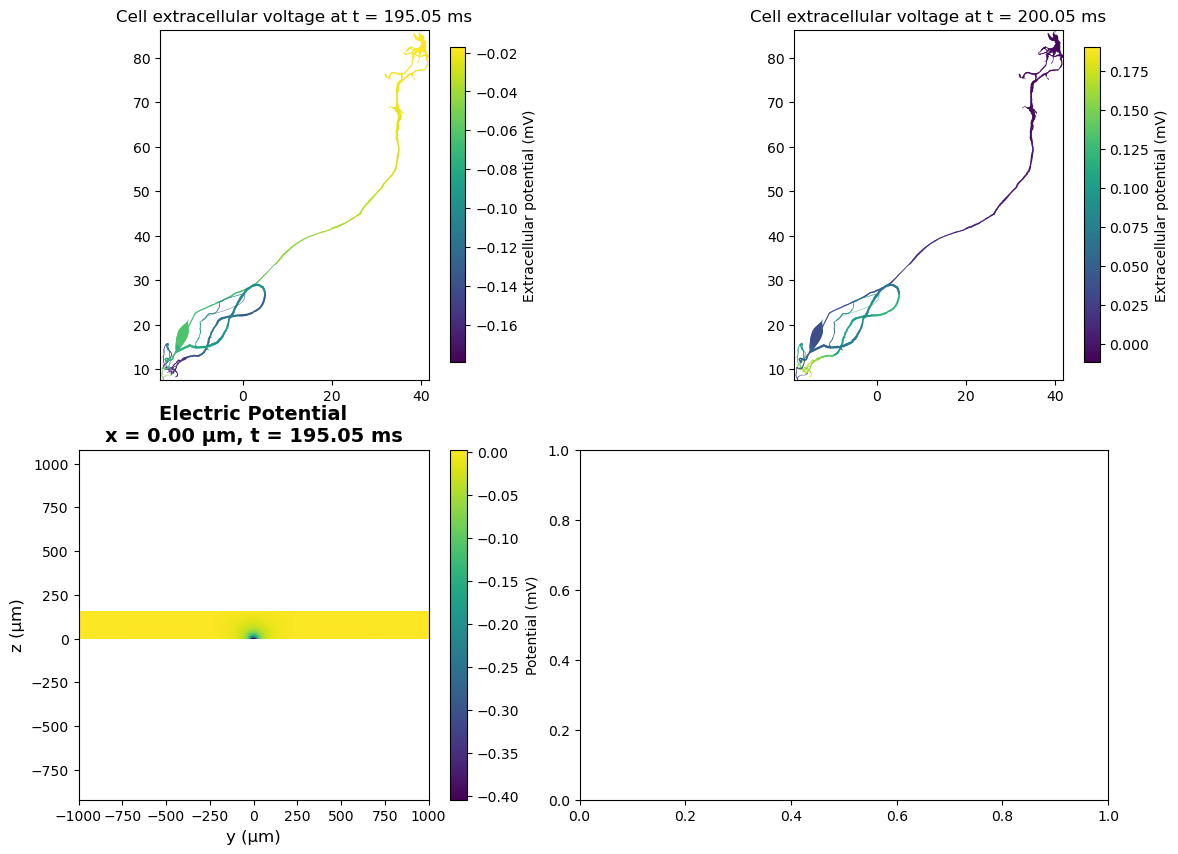

In [105]:
fig, ax = plt.subplots(2,2, figsize = (15,10))
retineuron.plot.plot_cell_extracellular_voltage(curly, sim, 0, ax = ax[0,0])
retineuron.plot.plot_electric_potential(v_field, 0, ax = ax[1,0], axis='x')

retineuron.plot.plot_cell_extracellular_voltage(curly, sim, 200, ax = ax[0,1])

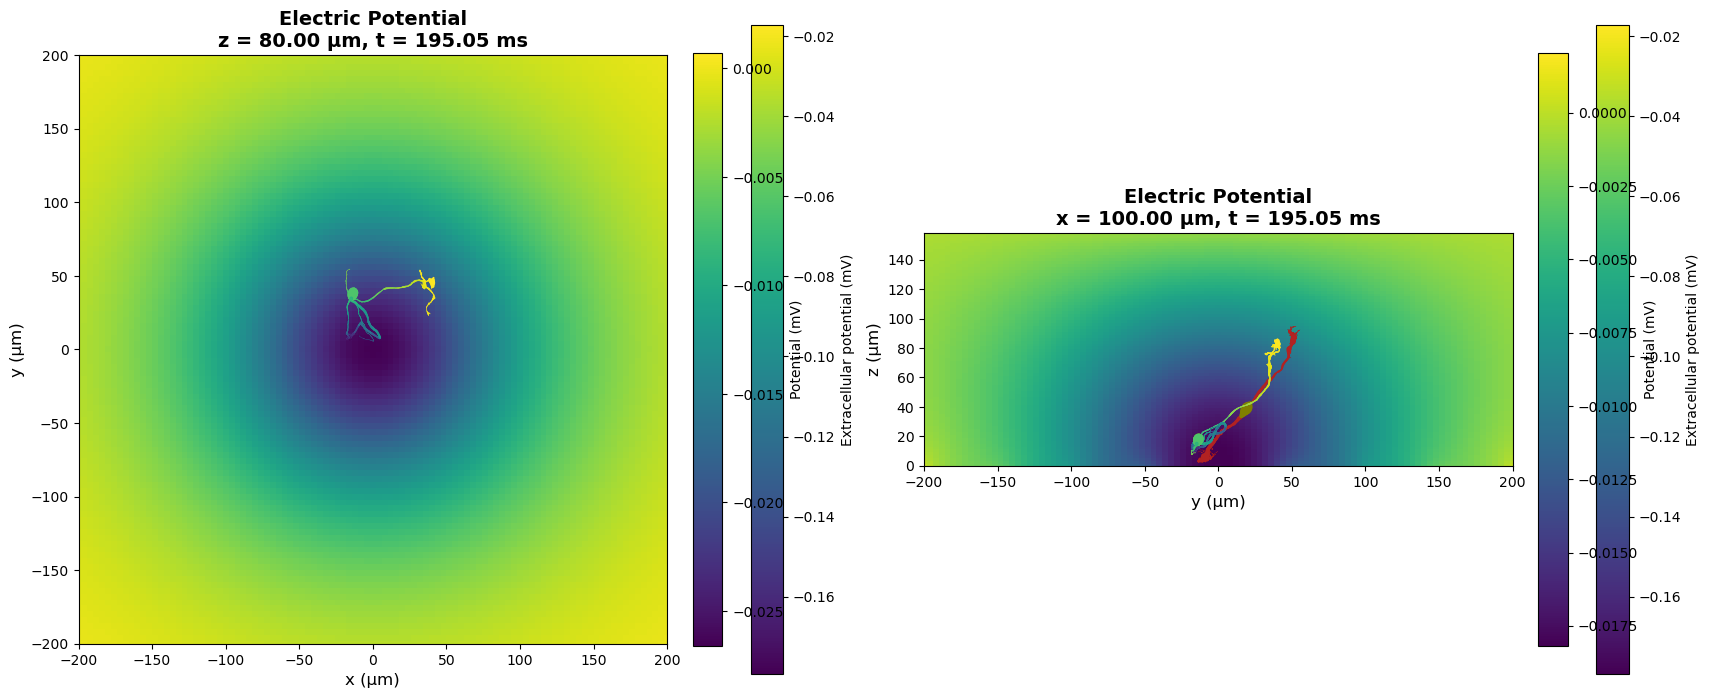

In [119]:
# Plot x-y plane at middle z, at time 10ms
t1=0
t2=200
fig, ax = plt.subplots(1,2, figsize = (20,10))

retineuron.plot.plot_cell_extracellular_voltage(curly, sim, t1, ax = ax[0], x='x', y='z')

retineuron.plot.plot_electric_potential(v_field, time=t1, axis='z', ax = ax[0],
                                                 xlim = (-200,200),
                                                 ylim = (-200,200))



skpl.plot_tools.plot_verts(verts_2, edges_2, radius = swc2['radius'], x = 'x', y = 'y', ax = ax[1],
                               skel_color_map={3: 'firebrick', 4: 'salmon', 2: 'steelblue', 1: 'olive',},
                                  plot_soma = False, soma_size = 300, skel_colors = swc2['type'],
                          line_width=2)
skpl.plot_tools.plot_verts(verts_1, edges_1, radius = swc1['radius'], x = 'x', y = 'y', ax = ax[1],
                               skel_color_map={3: 'steelblue', 4: 'salmon', 2: 'steelblue', 1: 'olive',},
                                  plot_soma = False, soma_size = 300, skel_colors = swc1['type'],
                          line_width=2)


# Plot y-z plane at specific x coordinate
retineuron.plot.plot_cell_extracellular_voltage(curly, sim, t1, ax = ax[1], x='x', y='y')
fig, ax = retineuron.plot.plot_electric_potential(v_field, time=t1, axis='x', index=100.0,
                                                 xlim = (-200,200), ax = ax[1])